In [ ]:
from google.colab import drive
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

#Connecting with drive
drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/"
drive_file = "ACLED Data_2026-03-10.csv"

data_path = drive_path + drive_file

if os.path.exists(data_path):
  df = pd.read_csv(data_path)
  print("Data loaded successfully!")
else:
  print("File not found. Please checkk the path")

Mounted at /content/drive
Data loaded successfully!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78418 entries, 0 to 78417
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id_cnty       78418 non-null  object 
 1   event_date          78418 non-null  object 
 2   year                78418 non-null  int64  
 3   time_precision      78418 non-null  int64  
 4   disorder_type       78418 non-null  object 
 5   event_type          78418 non-null  object 
 6   sub_event_type      78418 non-null  object 
 7   actor1              78418 non-null  object 
 8   assoc_actor_1       19987 non-null  object 
 9   inter1              78418 non-null  object 
 10  actor2              53437 non-null  object 
 11  assoc_actor_2       14783 non-null  object 
 12  inter2              53437 non-null  object 
 13  interaction         78418 non-null  object 
 14  civilian_targeting  14626 non-null  object 
 15  iso                 78418 non-null  int64  
 16  regi

In [ ]:
#Changing types to best datatypes
df = df.convert_dtypes()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78418 entries, 0 to 78417
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id_cnty       78418 non-null  string 
 1   event_date          78418 non-null  string 
 2   year                78418 non-null  Int64  
 3   time_precision      78418 non-null  Int64  
 4   disorder_type       78418 non-null  string 
 5   event_type          78418 non-null  string 
 6   sub_event_type      78418 non-null  string 
 7   actor1              78418 non-null  string 
 8   assoc_actor_1       19987 non-null  string 
 9   inter1              78418 non-null  string 
 10  actor2              53437 non-null  string 
 11  assoc_actor_2       14783 non-null  string 
 12  inter2              53437 non-null  string 
 13  interaction         78418 non-null  string 
 14  civilian_targeting  14626 non-null  string 
 15  iso                 78418 non-null  Int64  
 16  regi

In [ ]:
#Event date is a string. We must convert it into datetime
date_cols = [col for col in df.columns if any(word in col.lower() for word in ['date'])]

for col in date_cols:
  df[col] = pd.to_datetime(df[col], errors = 'coerce')
print(f"Converted columns: {date_cols}")

Converted columns: ['event_date']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78418 entries, 0 to 78417
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id_cnty       78418 non-null  string        
 1   event_date          78418 non-null  datetime64[ns]
 2   year                78418 non-null  Int64         
 3   time_precision      78418 non-null  Int64         
 4   disorder_type       78418 non-null  string        
 5   event_type          78418 non-null  string        
 6   sub_event_type      78418 non-null  string        
 7   actor1              78418 non-null  string        
 8   assoc_actor_1       19987 non-null  string        
 9   inter1              78418 non-null  string        
 10  actor2              53437 non-null  string        
 11  assoc_actor_2       14783 non-null  string        
 12  inter2              53437 non-null  string        
 13  interaction         78418 non-null  string    

In [ ]:
#Removing duplicated rows
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
78413,False
78414,False
78415,False
78416,False


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
int(df.duplicated().sum())

0

In [ ]:
text_columns = df.select_dtypes(include = ['object', 'string', 'string[pyarrow]']).columns

In [ ]:
for col in text_columns:
  if 'actor' in col.lower():
    df[col] = df[col].fillna('None')

  elif any(word in col.lower() for word in ['admin', 'location', 'region']):
    df[col] = df[col].fillna('Unknown')

  else:
    df[col] = df[col].fillna('Unspecified')

print('Automated Cleaning Done!')

Automated Cleaning Done!


In [ ]:
df[text_columns].apply(lambda x: x.str.startswith(' ') | x.str.endswith(' ')).sum()

,0
event_id_cnty,0
disorder_type,0
event_type,0
sub_event_type,0
actor1,0
assoc_actor_1,0
inter1,0
actor2,0
assoc_actor_2,0
inter2,0


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns

In [ ]:
df[num_cols] = df[num_cols].fillna(0)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head(20)

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,MMR11104,2021-02-01,2021,1,Political violence,Explosions/Remote violence,Shelling/artillery/missile attack,Military Forces of Myanmar (2021-),None,State forces,None,None,Unspecified,State forces only,Unspecified,104,Southeast Asia,Myanmar,Kayin,Hpapun,Hpapun,Hpapun,18.065,97.4449,2,Twitter,New media,"On 1 February 2021, in Hpapun township (Hpapun...",0,Unspecified,1665526398
1,MMR11055,2021-02-01,2021,1,Strategic developments,Strategic developments,Other,Military Forces of Myanmar (2021-),None,State forces,None,None,Unspecified,State forces only,Unspecified,104,Southeast Asia,Myanmar,Nay Pyi Taw,Nay Pyi Taw,Unknown,Nay Pyi Taw,19.745,96.1297,3,Myanmar Times; Radio Free Asia,National-Regional,"Coup/military takeover: On 1 February 2021, My...",0,Unspecified,1709061537
2,MMR43562,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),Former Government of Myanmar (2016-); NLD: Nat...,Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Nay Pyi Taw,Nay Pyi Taw,Unknown,Nay Pyi Taw,19.745,96.1297,2,Radio Free Asia,Regional,"On 1 February 2021, in Nay Pyi Taw city (Nay P...",0,Unspecified,1709061542
3,MMR22414,2021-02-01,2021,1,Demonstrations,Protests,Peaceful protest,Protesters (Myanmar),None,Protesters,None,None,Unspecified,Protesters only,Unspecified,104,Southeast Asia,Myanmar,Sagaing,Shwebo,Taze,Taze,22.944,95.3736,1,Radio Free Asia,Regional,"On 1 February 2021, in Taze town (Taze Townshi...",0,crowd size=no report,1719352865
4,MMR21508,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),Police Forces of Myanmar (2021-),State forces,Civilians (Myanmar),Government of Myanmar (2016-); NLD: National L...,Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Kachin,Mohnyin,Hpakant,Hpakant,25.6138,96.3148,1,Radio Free Asia,Regional,"On 1 February 2021, in Hpakant town (Hpakant T...",0,Unspecified,1726526139
5,MMR85112,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),Former Government of Myanmar (2016-); NLD: Nat...,Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Nay Pyi Taw,Det Khi Na,Za Bu Thi Ri,Za Bu Thi Ri,19.7686,96.0726,2,Independent Mon News Agency,National,"On 1 February 2021, in Za Bu Thi Ri township (...",0,Unspecified,1736895192
6,MMR87114,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),Government of Myanmar (2016-),Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Kachin,Myitkyina,Myitkyina,Myitkyina,25.3832,97.3963,1,Kachin News Group; Khit Thit Media; Mizzima; S...,Subnational-National,"On 1 February 2021, in Myitkyina town (Myitkyi...",0,Unspecified,1737495256
7,MMR62259,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),Government of Myanmar (2016-); Lawyers (Myanmar),Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Sagaing,Monywa,Monywa,Monywa,22.1086,95.1358,1,Democratic Voice of Burma,National,"On 1 February 2021, in Monywa town, Monywa tow...",0,Unspecified,1744085413
8,MMR85820,2021-02-01,2021,1,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),None,Civilians,State forces-Civilians,Unspecified,104,Southeast Asia,Myanmar,Yangon,Yangon-East,Mingalartaungnyunt,Yangon - Mingalartaungnyunt,16.7892,96.1784,1,Forum

In [ ]:
#Checking missing value in each column
print(df.isnull().sum())


event_id_cnty         0
event_date            0
year                  0
time_precision        0
disorder_type         0
event_type            0
sub_event_type        0
actor1                0
assoc_actor_1         0
inter1                0
actor2                0
assoc_actor_2         0
inter2                0
interaction           0
civilian_targeting    0
iso                   0
region                0
country               0
admin1                0
admin2                0
admin3                0
location              0
latitude              0
longitude             0
geo_precision         0
source                0
source_scale          0
notes                 0
fatalities            0
tags                  0
timestamp             0
dtype: int64


In [ ]:
# စာသား column တွေရဲ့ ပထမဆုံး ၅ ကြောင်းကို ကြည့်မယ်
df[text_columns].head()

,event_id_cnty,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,region,country,admin1,admin2,admin3,location,source,source_scale,notes,tags
0,MMR11104,Political violence,Explosions/Remote violence,Shelling/artillery/missile attack,Military Forces of Myanmar (2021-),None,State forces,None,None,Unspecified,State forces only,Unspecified,Southeast Asia,Myanmar,Kayin,Hpapun,Hpapun,Hpapun,Twitter,New media,"On 1 February 2021, in Hpapun township (Hpapun...",Unspecified
1,MMR11055,Strategic developments,Strategic developments,Other,Military Forces of Myanmar (2021-),None,State forces,None,None,Unspecified,State forces only,Unspecified,Southeast Asia,Myanmar,Nay Pyi Taw,Nay Pyi Taw,Unknown,Nay Pyi Taw,Myanmar Times; Radio Free Asia,National-Regional,"Coup/military takeover: On 1 February 2021, My...",Unspecified
2,MMR43562,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),None,State forces,Civilians (Myanmar),Former Government of Myanmar (2016-); NLD: Nat...,Civilians,State forces-Civilians,Unspecified,Southeast Asia,Myanmar,Nay Pyi Taw,Nay Pyi Taw,Unknown,Nay Pyi Taw,Radio Free Asia,Regional,"On 1 February 2021, in Nay Pyi Taw city (Nay P...",Unspecified
3,MMR22414,Demonstrations,Protests,Peaceful protest,Protesters (Myanmar),None,Protesters,None,None,Unspecified,Protesters only,Unspecified,Southeast Asia,Myanmar,Sagaing,Shwebo,Taze,Taze,Radio Free Asia,Regional,"On 1 February 2021, in Taze town (Taze Townshi...",crowd size=no report
4,MMR21508,Strategic developments,Strategic developments,Arrests,Military Forces of Myanmar (2021-),Police Forces of Myanmar (2021-),State forces,Civilians (Myanmar),Government of Myanmar (2016-); NLD: National L...,Civilians,State forces-Civilians,Unspecified,Southeast Asia,Myanmar,Kachin,Mohnyin,Hpakant,Hpakant,Radio Free Asia,Regional,"On 1 February 2021, in Hpakant town (Hpakant T...",Unspecified


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78418 entries, 0 to 78417
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id_cnty       78418 non-null  string        
 1   event_date          78418 non-null  datetime64[ns]
 2   year                78418 non-null  Int64         
 3   time_precision      78418 non-null  Int64         
 4   disorder_type       78418 non-null  string        
 5   event_type          78418 non-null  string        
 6   sub_event_type      78418 non-null  string        
 7   actor1              78418 non-null  string        
 8   assoc_actor_1       78418 non-null  string        
 9   inter1              78418 non-null  string        
 10  actor2              78418 non-null  string        
 11  assoc_actor_2       78418 non-null  string        
 12  inter2              78418 non-null  string        
 13  interaction         78418 non-null  string    

In [ ]:
#Prove that no missing value
total_missing = df.isnull().sum().sum()

In [ ]:
total_missing

np.int64(0)

In [ ]:
#Prove that all datatypes are correct
data_type = df.dtypes.value_counts()

In [ ]:
data_type

,count
string[python],22
Int64,6
Float64,2
datetime64[ns],1


In [ ]:
df.shape

(78418, 31)

In [ ]:
#Checking if there are missing percerntage
missing_data = df.isnull().sum()
missing_percent = (missing_data/len(df)) *100


In [ ]:
#Showing with tables
quality_df = pd.DataFrame({'Missing Values' : missing_data, 'Percentage(%)': missing_percent})
print("--- Data Quality Check---")
print(quality_df[quality_df['Missing Values']>0])

--- Data Quality Check---
Empty DataFrame
Columns: [Missing Values, Percentage(%)]
Index: []


In [ ]:
quality_df

,Missing Values,Percentage(%)
event_id_cnty,0,0.0
event_date,0,0.0
year,0,0.0
time_precision,0,0.0
disorder_type,0,0.0
event_type,0,0.0
sub_event_type,0,0.0
actor1,0,0.0
assoc_actor_1,0,0.0
inter1,0,0.0


In [ ]:
print("--- Data Quality Check---")
print(quality_df[quality_df['Missing Values']>0])

--- Data Quality Check---
Empty DataFrame
Columns: [Missing Values, Percentage(%)]
Index: []


In [ ]:
#။ Summary Statistics for Key Variables (အဓိက ကိန်းဂဏန်းများ)
#fatalities (သေဆုံးမှု) လိုမျိုး ကိန်းဂဏန်းတွေနဲ့ event_type လိုမျိုး အမျိုးအစားတွေကို ခြုံငုံသုံးသပ်ပါမယ်။

# ကိန်းဂဏန်းဒေတာများ၏ အနှစ်ချုပ် (Mean, Max, Min စသည်)

print("\n--- Numerical Summary (Fatalities) ---")
print(df['fatalities'].describe())


--- Numerical Summary (Fatalities) ---
count     78418.0
mean     1.038907
std      4.363883
min           0.0
25%           0.0
50%           0.0
75%           1.0
max         400.0
Name: fatalities, dtype: Float64


In [ ]:
# ဖြစ်စဉ်အမျိုးအစားအလိုက် အရေအတွက်ကို ရာခိုင်နှုန်းနဲ့ ကြည့်ခြင်း
event_distribution = df['event_type'].value_counts(normalize=True) * 100
print("\n--- Event Type Distribution (%) ---")
print(event_distribution)



--- Event Type Distribution (%) ---
event_type
Explosions/Remote violence    25.401056
Battles                       23.639981
Strategic developments        20.603688
Protests                      18.832411
Violence against civilians    11.443801
Riots                          0.079063
Name: proportion, dtype: Float64


In [ ]:
# ဘယ်ဒေသတွေမှာ ဖြစ်စဉ် (Events) အများဆုံးလဲ
top_regions = df['admin1'].value_counts()
print("\n--- Top 10 Active Regions ---")
print(top_regions)


--- Top 10 Active Regions ---
admin1
Sagaing        23048
Magway          7637
Mandalay        7381
Yangon          4992
Tanintharyi     4732
Shan-North      4633
Kachin          4034
Rakhine         3789
Kayin           2940
Bago-East       2823
Mon             2778
Chin            2254
Shan-South      2065
Kayah           1742
Ayeyarwady      1557
Bago-West       1456
Nay Pyi Taw      444
Shan-East        113
Name: count, dtype: Int64


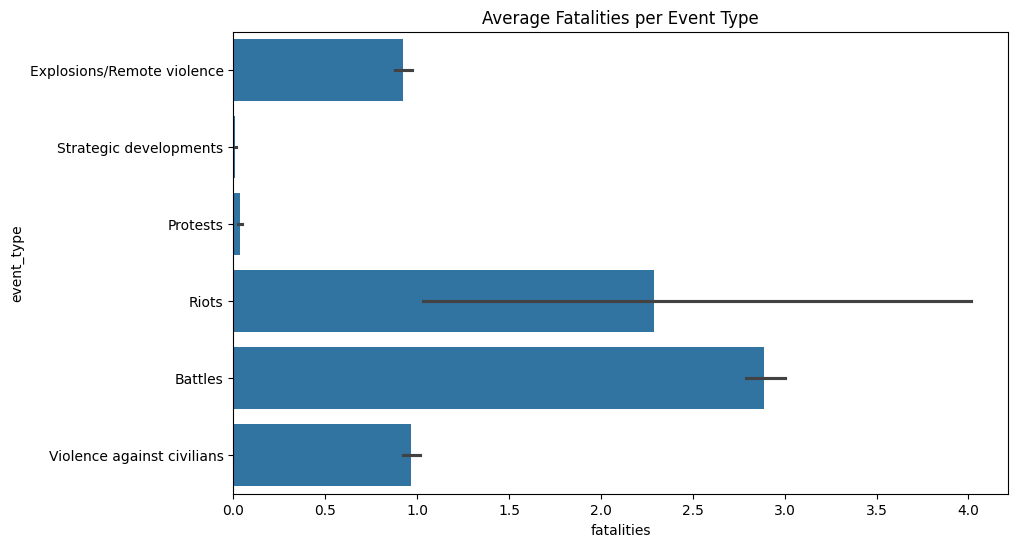

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = df, x = 'fatalities', y = 'event_type', estimator='mean')
plt.title('Average Fatalities per Event Type')
plt.show()

count     78418.0
mean     1.038907
std      4.363883
min           0.0
25%           0.0
50%           0.0
75%           1.0
max         400.0
Name: fatalities, dtype: Float64


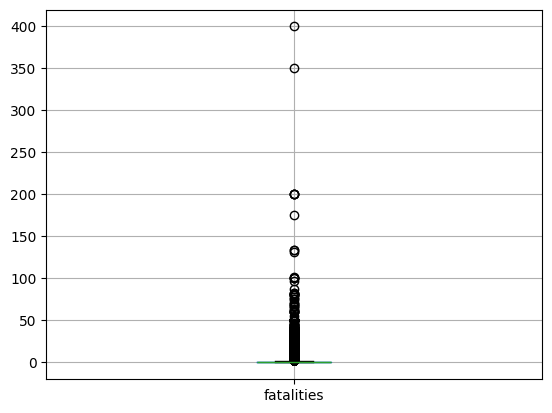

In [ ]:
# ကိန်းဂဏန်းတွေရဲ့ အကျဉ်းချုပ်ကြည့်ရန်
print(df['fatalities'].describe())

# Boxplot ဆွဲပြီး မျက်မြင်စစ်ဆေးရန်
import matplotlib.pyplot as plt
df.boxplot(column=['fatalities'])
plt.show()


In [ ]:
outlier